<a href="https://colab.research.google.com/github/MyrtoKar/Projects/blob/dev/energy_forecasting_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔋 Energy Forecasting and Anomaly Detection
This Colab notebook forecasts household energy usage using an LSTM model and detects anomalies using residual analysis.

In [ ]:
# 📦 Install & import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import datetime

sns.set(style="whitegrid")

In [ ]:
# 📂 Upload the dataset manually or use this path if already uploaded in Colab
df = pd.read_csv("/content/small_energy_dataset.csv", parse_dates=["Timestamp"])
df.set_index("Timestamp", inplace=True)
df.head()

,Global_active_power
Timestamp,
2023-01-01 00:00:00,1.225
2023-01-01 00:15:00,1.206
2023-01-01 00:30:00,1.259
2023-01-01 00:45:00,1.316
2023-01-01 01:00:00,1.242


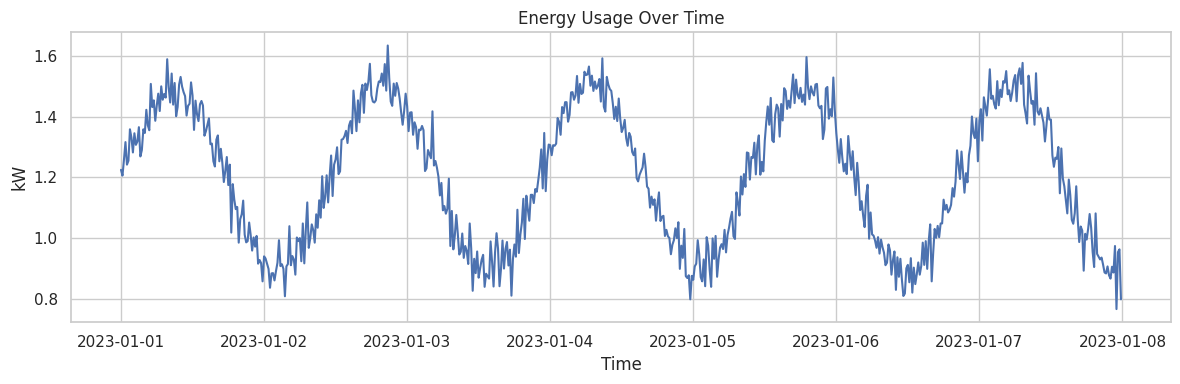

In [ ]:
# 📈 Visualize the time series
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Global_active_power'])
plt.title("Energy Usage Over Time")
plt.ylabel("kW")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [ ]:
# 🧹 Scale the data for LSTM
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

# Create sequences
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_len = 24  # 6 hours
X, y = create_sequences(df_scaled, seq_len)
X.shape, y.shape

((648, 24, 1), (648, 1))

In [ ]:
# 📚 Train/Test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# 🧠 Build LSTM Model
model = Sequential([
    LSTM(64, input_shape=(seq_len, 1), return_sequences=False),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 🎯 Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=32,
                    validation_split=0.1, verbose=1)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.1830 - val_loss: 0.0476
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0193 - val_loss: 0.0079
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0111 - val_loss: 0.0187
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0100 - val_loss: 0.0101
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0083 - val_loss: 0.0096
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0081 - val_loss: 0.0089
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0066 - val_loss: 0.0070
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0059 - val_loss: 0.0061
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0061 - val_loss: 0.0044
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0061 - val_loss: 0.0040


In [ ]:
# 🔍 Predict and inverse transform
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

# Compute residuals for anomaly detection
residuals = np.abs(y_test_inv - y_pred_inv)
threshold = np.percentile(residuals, 95)
anomalies = residuals > threshold

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


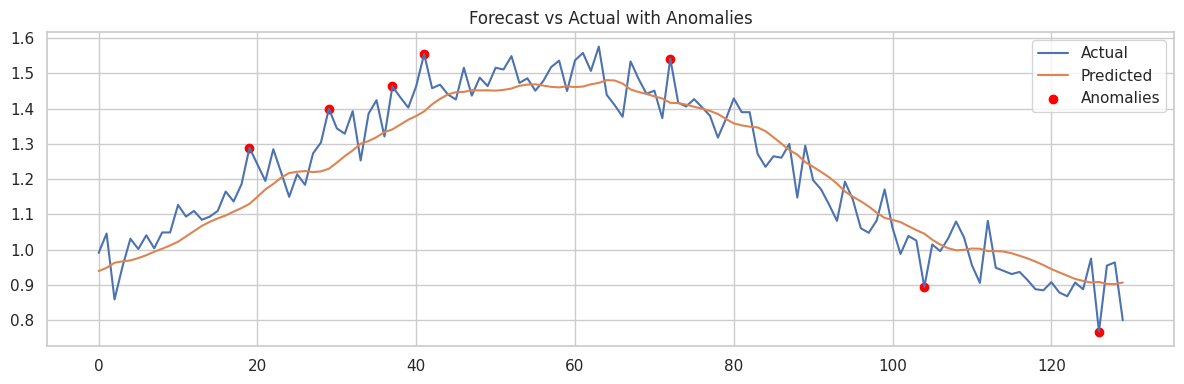

In [ ]:
# 📊 Plot predictions and anomalies
plt.figure(figsize=(12,4))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.scatter(np.arange(len(y_pred_inv))[anomalies.flatten()],
            y_test_inv[anomalies.flatten()], color='red', label='Anomalies')
plt.legend()
plt.title("Forecast vs Actual with Anomalies")
plt.tight_layout()
plt.show()